In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [3]:
# Load Wine Quality dataset

df = pd.read_csv("../dataset/winequality-red.csv", sep=";")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Inspect dataset structure

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
# Descriptive statistics

print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values.to_frame("Missing Count"))

print("Total missing values:", df.isnull().sum().sum())

Missing values in each column:


,Missing Count
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Total missing values: 0


In [7]:
# Analyze wine quality score distribution

print("Wine Quality Score Distribution:")
display(df["quality"].value_counts().sort_index())

Wine Quality Score Distribution:


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

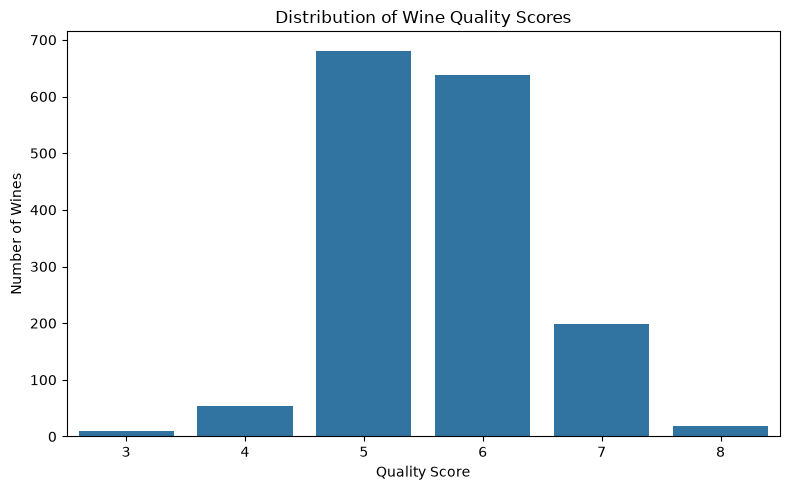

In [8]:
# Plot quality score distribution

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")

plt.tight_layout()
plt.show()

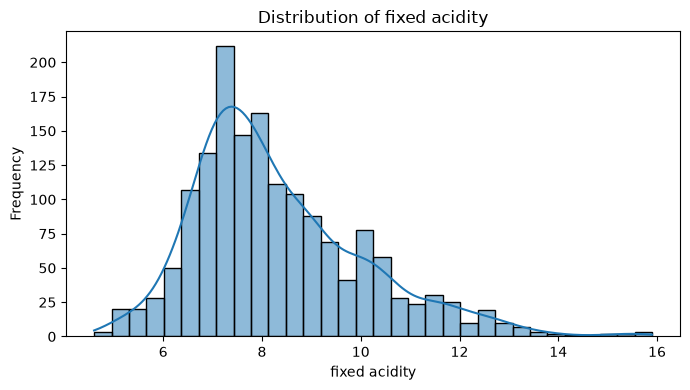

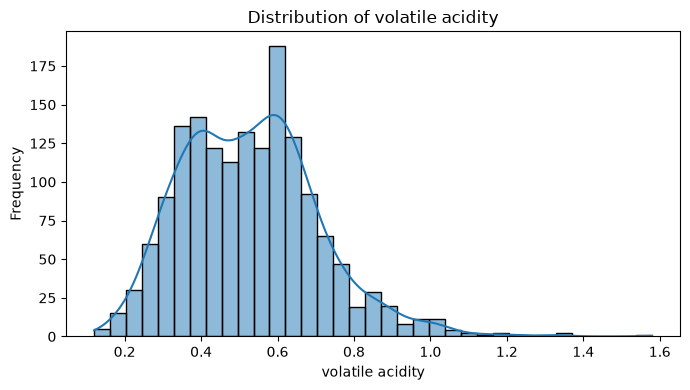

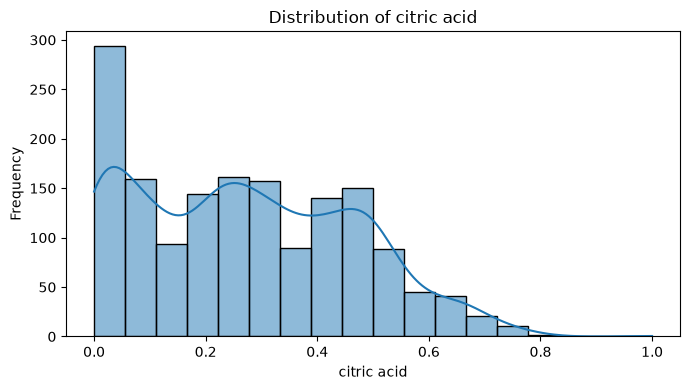

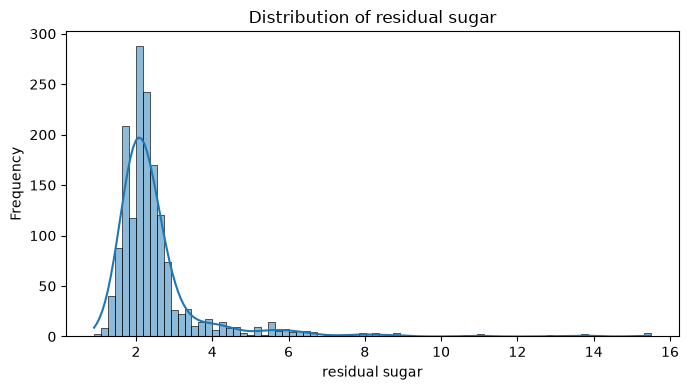

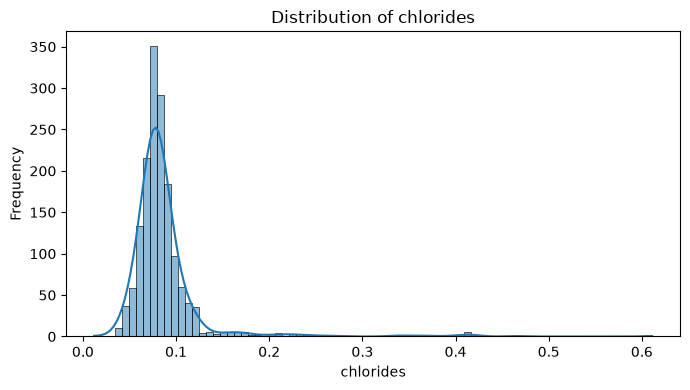

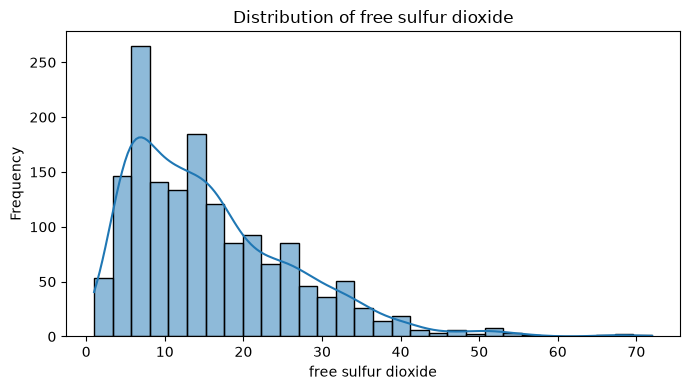

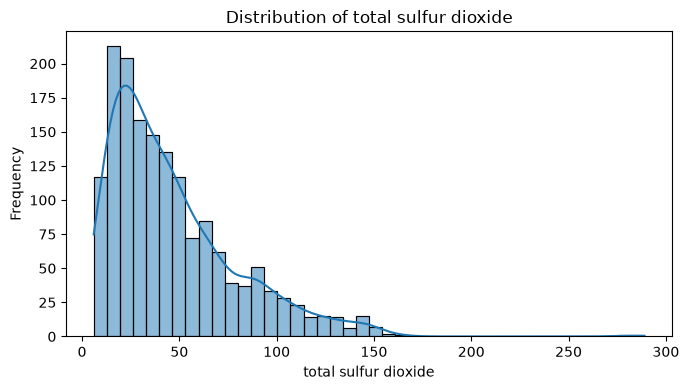

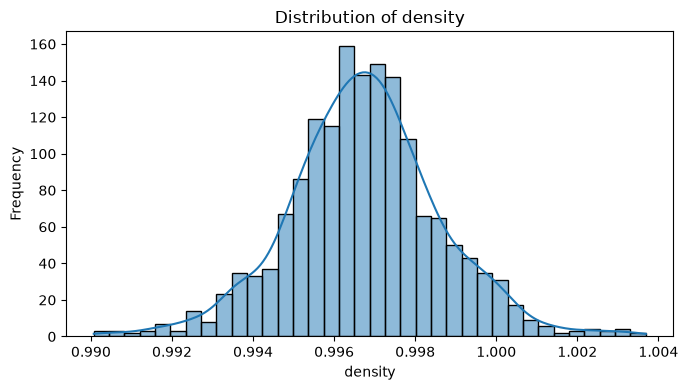

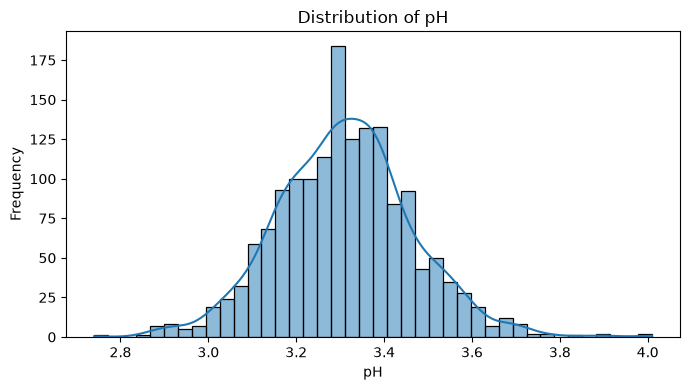

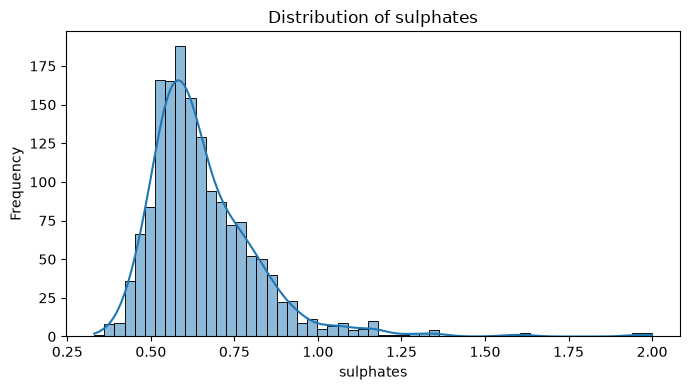

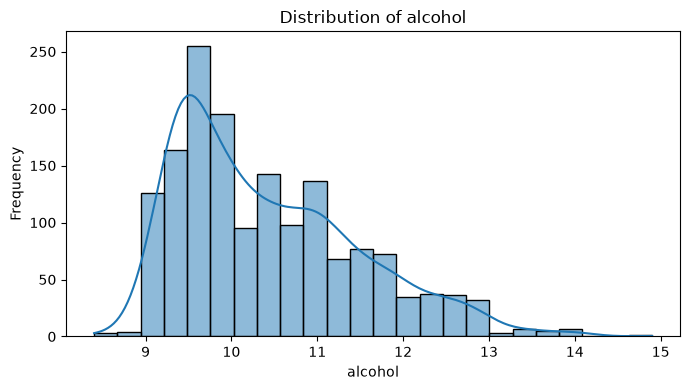

In [9]:
# Distribution plots for chemical features

features = df.columns.drop("quality")

for column in features:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[column], kde=True)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

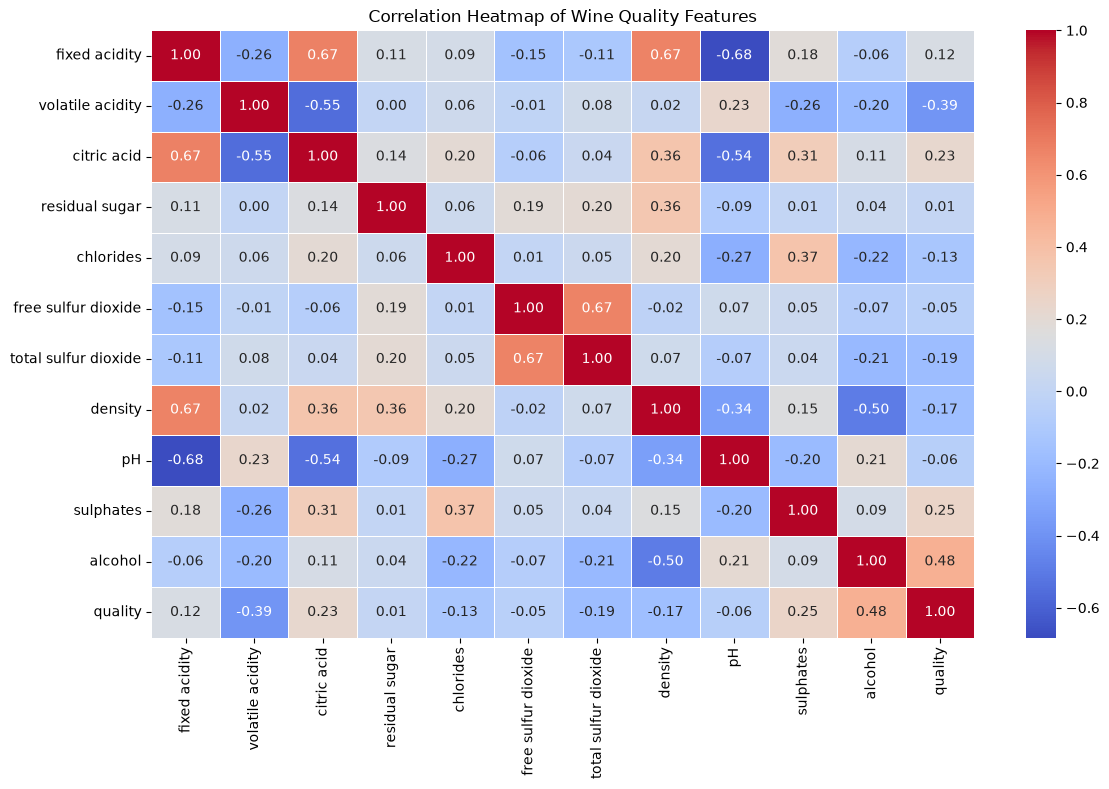

In [10]:
# Correlation analysis

correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Quality Features")
plt.tight_layout()
plt.show()

In [11]:
# Convert wine quality into binary classes

df["quality_label"] = (df["quality"] >= 6).astype(int)

print("Binary Quality Class Distribution:")
display(df["quality_label"].value_counts().sort_index())

print("\nClass Definition:")
print("0 = Not Good (Quality < 6)")
print("1 = Good (Quality >= 6)")

Binary Quality Class Distribution:


quality_label
0    744
1    855
Name: count, dtype: int64


Class Definition:
0 = Not Good (Quality < 6)
1 = Good (Quality >= 6)


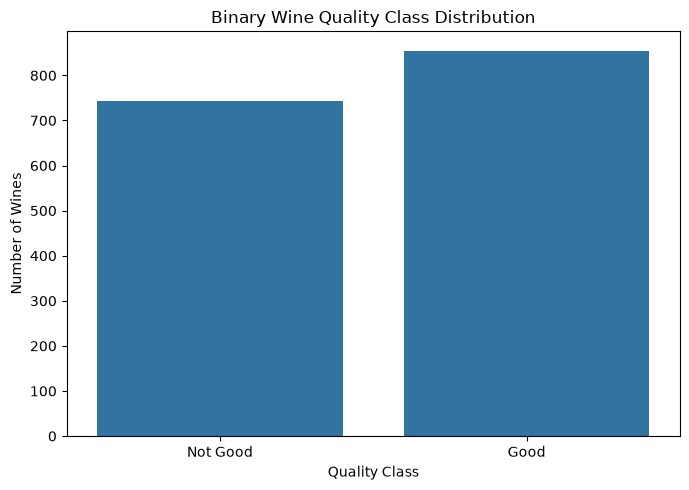

In [12]:
# Visualize binary class distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="quality_label")

plt.title("Binary Wine Quality Class Distribution")
plt.xlabel("Quality Class")
plt.ylabel("Number of Wines")
plt.xticks([0, 1], ["Not Good", "Good"])

plt.tight_layout()
plt.show()

In [13]:
# Prepare features and target

X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of input features:", X.shape[1])

Feature matrix shape: (1599, 11)
Target shape: (1599,)
Number of input features: 11


In [14]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])

Training samples: 1279
Testing samples: 320
Training features: 11


In [15]:
# Standardize features for SGD and SVC

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [16]:
# Train Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest trained successfully!")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest trained successfully!
Random Forest Accuracy: 0.8156


In [17]:
# Random Forest classification report

print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Not Good", "Good"]
))

Random Forest Classification Report:
              precision    recall  f1-score   support

    Not Good       0.79      0.82      0.81       149
        Good       0.84      0.81      0.82       171

    accuracy                           0.82       320
   macro avg       0.81      0.82      0.82       320
weighted avg       0.82      0.82      0.82       320



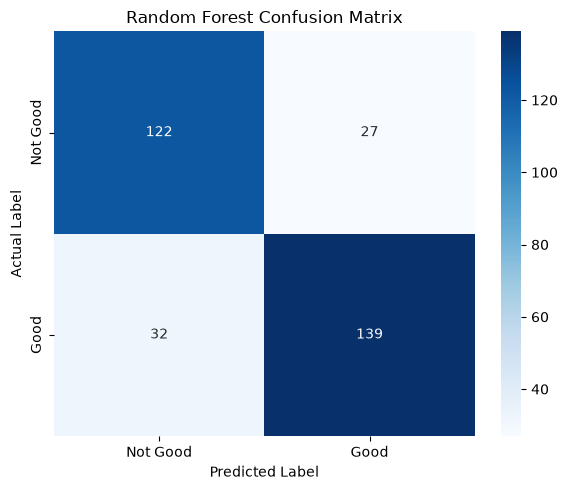

In [18]:
# Random Forest confusion matrix

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Good", "Good"],
    yticklabels=["Not Good", "Good"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [19]:
# Train Stochastic Gradient Descent classifier

sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

sgd_pred = sgd_model.predict(X_test_scaled)

sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Classifier trained successfully!")
print(f"SGD Accuracy: {sgd_accuracy:.4f}")

SGD Classifier trained successfully!
SGD Accuracy: 0.6562


In [20]:
# SGD classification report

print("SGD Classification Report:")
print(classification_report(
    y_test,
    sgd_pred,
    target_names=["Not Good", "Good"]
))

SGD Classification Report:
              precision    recall  f1-score   support

    Not Good       0.65      0.56      0.60       149
        Good       0.66      0.74      0.70       171

    accuracy                           0.66       320
   macro avg       0.66      0.65      0.65       320
weighted avg       0.66      0.66      0.65       320



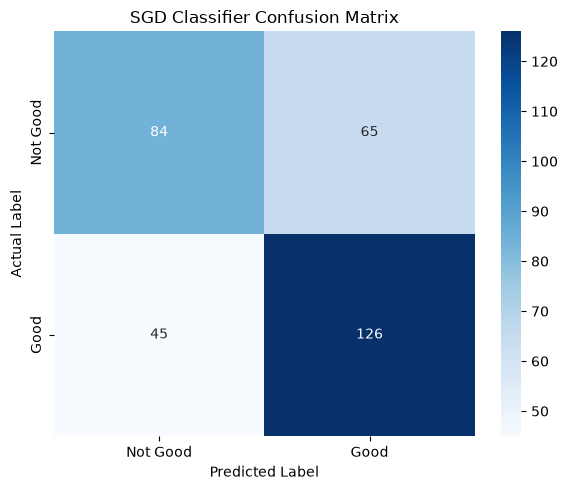

In [21]:
# SGD confusion matrix

sgd_cm = confusion_matrix(y_test, sgd_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Good", "Good"],
    yticklabels=["Not Good", "Good"]
)

plt.title("SGD Classifier Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [22]:
# Train Support Vector Classifier

svc_model = SVC(
    kernel="rbf",
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

svc_pred = svc_model.predict(X_test_scaled)

svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC trained successfully!")
print(f"SVC Accuracy: {svc_accuracy:.4f}")

SVC trained successfully!
SVC Accuracy: 0.7625


In [23]:
# SVC classification report

print("SVC Classification Report:")
print(classification_report(
    y_test,
    svc_pred,
    target_names=["Not Good", "Good"]
))

SVC Classification Report:
              precision    recall  f1-score   support

    Not Good       0.72      0.81      0.76       149
        Good       0.81      0.72      0.76       171

    accuracy                           0.76       320
   macro avg       0.77      0.77      0.76       320
weighted avg       0.77      0.76      0.76       320



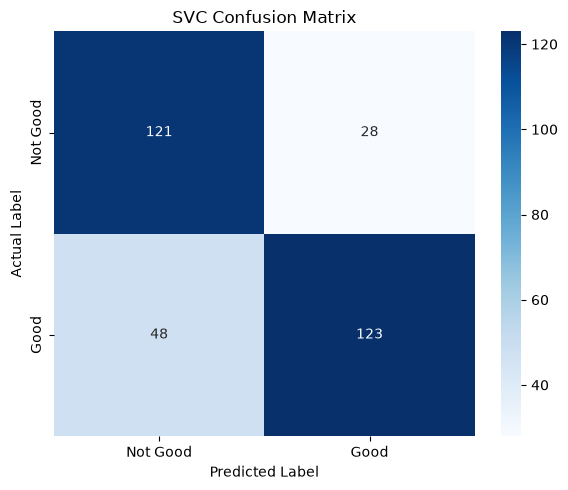

In [24]:
# SVC confusion matrix

svc_cm = confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Good", "Good"],
    yticklabels=["Not Good", "Good"]
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [25]:
# Compare model accuracies

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "SVC"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(model_comparison)

,Model,Accuracy
0,Random Forest,0.815625
1,SVC,0.762500
2,SGD Classifier,0.656250


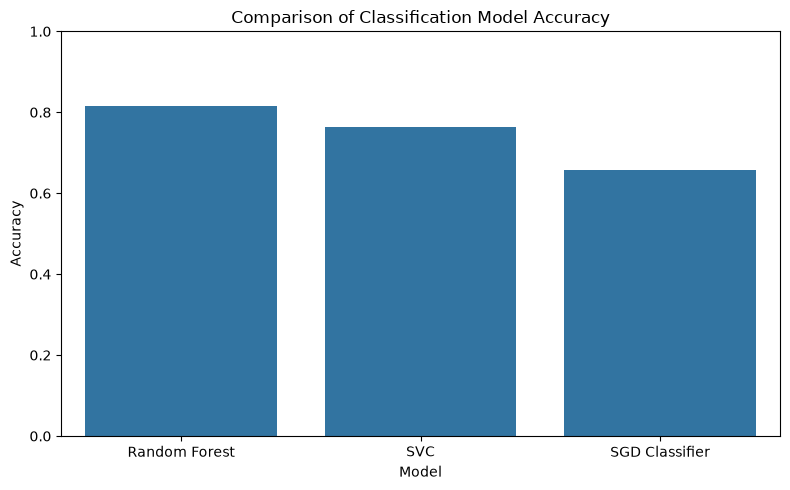

In [26]:
# Visualize model comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Comparison of Classification Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [27]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
display(feature_importance)

Random Forest Feature Importance:


,Feature,Importance
10,alcohol,0.178138
9,sulphates,0.138765
1,volatile acidity,0.113982
6,total sulfur dioxide,0.098226
7,density,0.090872
4,chlorides,0.070574
0,fixed acidity,0.068242
8,pH,0.066011
2,citric acid,0.061240
5,free sulfur dioxide,0.058907


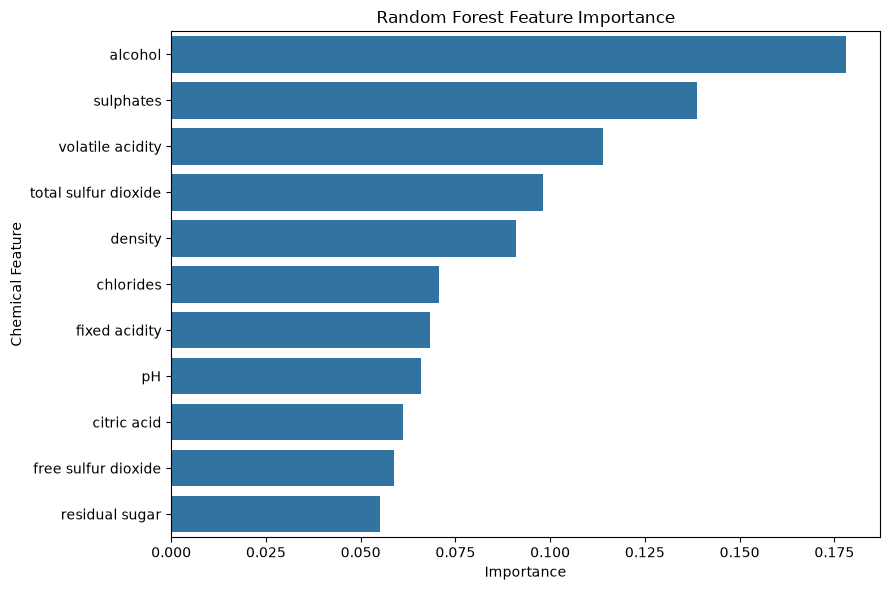

In [28]:
# Plot Random Forest feature importance

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Chemical Feature")

plt.tight_layout()
plt.show()

# Final Findings and Conclusion

## Findings

- The Wine Quality dataset contains 1,599 red-wine samples and 12 columns, including 11 physicochemical features and the original quality score.
- The dataset contained no missing values.
- The quality scores were concentrated mainly around scores 5 and 6.
- The original quality variable was converted into a binary classification target.
- Quality scores below 6 were classified as Not Good, while scores of 6 or above were classified as Good.
- The dataset was divided into 80% training data and 20% testing data using stratified sampling.
- StandardScaler was applied for the SGD and SVC models.
- Random Forest, SGD Classifier, and SVC were trained and evaluated.
- Accuracy, precision, recall, F1-score, and confusion matrices were used to evaluate the classifiers.
- Random Forest feature importance was used to identify the chemical properties that contributed most to classification.
- Alcohol showed the strongest positive correlation with wine quality, while volatile acidity showed the strongest negative correlation.
- The model comparison identified the classifier with the highest test accuracy as the most suitable model among the three evaluated approaches.

## Conclusion

The project successfully developed and evaluated machine-learning classifiers for predicting wine quality from physicochemical properties. Exploratory analysis showed that wine quality is influenced by multiple chemical characteristics rather than a single variable. The three classification algorithms provided a practical comparison of ensemble, linear, and kernel-based approaches. Based on the test-set results, the model with the highest accuracy provides the strongest classification performance for this dataset. The analysis demonstrates the importance of preprocessing, class analysis, feature evaluation, and systematic model comparison in a wine quality prediction problem.